# Hand Gesture Recognition using CNN

This project builds a **Convolutional Neural Network (CNN)** to classify
10 different hand gestures from the LeapGestRecog dataset (near-infrared
images captured by a Leap Motion sensor, across 10 subjects, ~20,000 images).

**Workflow:**
- Load color images and build a gesture label lookup dynamically from
  the folder structure
- Normalize pixel values and one-hot encode labels
- Split data randomly (stratified across all 10 gesture classes)
- Build a CNN with Batch Normalization, Spatial Dropout, and Global
  Average Pooling
- Apply data augmentation (rotation, shift, zoom, brightness)
- Train with Early Stopping to prevent overfitting
- Evaluate using accuracy, a classification report, and a confusion matrix
- Run 3-fold stratified cross-validation to check result consistency

**Technologies used:** Python, OpenCV, TensorFlow/Keras, Scikit-Learn

**Result:** ~99.9% test accuracy.

**Important caveat:** This uses a random, stratified split across all
subjects, not a subject-based split. Since consecutive video frames of
the same person performing the same gesture look nearly identical, this
split likely allows near-duplicate images to appear in both the training
and test sets, which can inflate accuracy compared to how the model would
perform on a genuinely new, unseen person. A separate experiment using a
subject-based split (holding out entire subjects for testing) produced a
more conservative accuracy of ~78%, which may better reflect real-world
performance for a new user of a gesture-based control system.



In [18]:
# IMPORTS

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, SpatialDropout2D,
    GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

import kagglehub



In [19]:
# DOWNLOAD THE DATASET

path = kagglehub.dataset_download("gti-upm/leapgestrecog")
dataset_path = os.path.join(path, "leapGestRecog")

print("Dataset downloaded to:", dataset_path)

Using Colab cache for faster access to the 'leapgestrecog' dataset.
Dataset downloaded to: /kaggle/input/leapgestrecog/leapGestRecog


In [20]:
# BUILD GESTURE LABEL LOOKUP DYNAMICALLY

subjects = sorted(os.listdir(dataset_path))
gesture_names = sorted(os.listdir(os.path.join(dataset_path, subjects[0])))

lookup = {g: i for i, g in enumerate(gesture_names)}
reverse_lookup = {v: k for k, v in lookup.items()}

print("Gesture labels:", lookup)

Gesture labels: {'01_palm': 0, '02_l': 1, '03_fist': 2, '04_fist_moved': 3, '05_thumb': 4, '06_index': 5, '07_ok': 6, '08_palm_moved': 7, '09_c': 8, '10_down': 9}


In [21]:
# LOAD IMAGES (color, 64x64 - matches the architecture's input_shape)

IMG_WIDTH = IMG_HEIGHT = 64

images = []
labels = []

for subject in subjects:
    for gesture in gesture_names:
        folder = os.path.join(dataset_path, subject, gesture)
        for f in os.listdir(folder):
            img = cv2.imread(os.path.join(folder, f))
            if img is None:
                continue  # skip unreadable files
            img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
            images.append(img)
            labels.append(lookup[gesture])

print("Total images loaded:", len(images))



Total images loaded: 20000


In [22]:
# CONVERT TO ARRAYS, NORMALIZE, ONE-HOT ENCODE

X = np.array(images, dtype=np.float32) / 255.0
y = np.array(labels)
y_cat = to_categorical(y, len(gesture_names))

print("X shape:", X.shape)
print("y_cat shape:", y_cat.shape)



X shape: (20000, 64, 64, 3)
y_cat shape: (20000, 10)


In [23]:
# TRAIN / TEST SPLIT
# Random, stratified split - stratify=y keeps all 10 gesture classes
# evenly represented in both sets, but does NOT prevent near-duplicate
# frames of the same subject from appearing in both train and test.

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2,
    random_state=42, shuffle=True, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (16000, 64, 64, 3)
Test shape : (4000, 64, 64, 3)


In [24]:

# BUILD THE CNN MODEL

def build_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
        BatchNormalization(),
        MaxPooling2D(),
        SpatialDropout2D(0.10),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(),
        SpatialDropout2D(0.15),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(),
        SpatialDropout2D(0.20),

        GlobalAveragePooling2D(),

        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(len(gesture_names), activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_6             │ (None, 32, 32, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_7             │ (None, 16, 16, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_8             │ (None, 8, 8, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [25]:
# DATA AUGMENTATION (applied only during training)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    brightness_range=[0.8, 1.2]
)



In [26]:

# TRAIN THE MODEL

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop]
)


Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 174s 427ms/step - accuracy: 0.4485 - loss: 1.6173 - val_accuracy: 0.1903 - val_loss: 2.7678
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 205s 436ms/step - accuracy: 0.8198 - loss: 0.6067 - val_accuracy: 0.8931 - val_loss: 0.3710
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 198s 425ms/step - accuracy: 0.9338 - loss: 0.2586 - val_accuracy: 0.9953 - val_loss: 0.0476
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 202s 425ms/step - accuracy: 0.9695 - loss: 0.1314 - val_accuracy: 0.9978 - val_loss: 0.0187
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 168s 420ms/step - accuracy: 0.9829 - loss: 0.0795 - val_accuracy: 0.9987 - val_loss: 0.0136
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 168s 421ms/step - accuracy: 0.9895 - loss: 0.0521 - val_accuracy: 0.9991 - val_loss: 0.0041
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 169s 424ms/step - accuracy: 0.9920 - loss: 0.0387 - val_accuracy: 0.9991 - val_loss: 0.0072
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 169s 421ms/step - accuracy: 0.9928 -

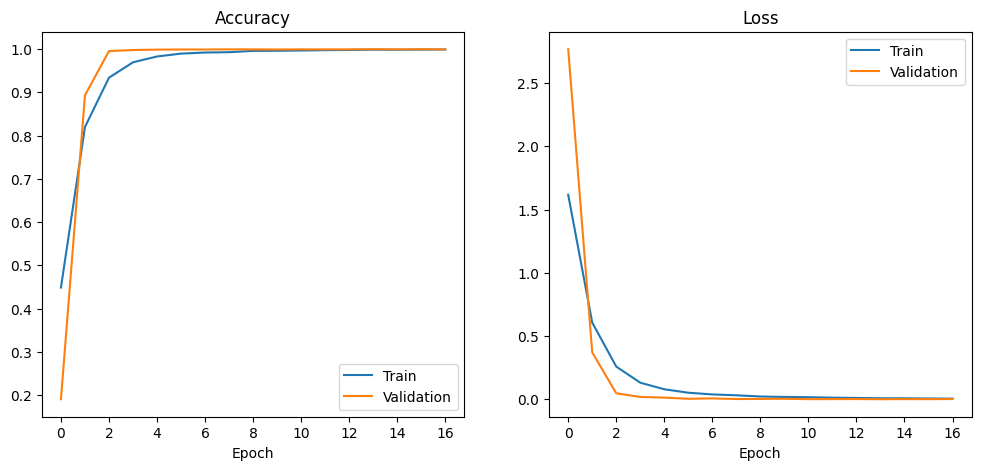

In [27]:
# PLOT TRAINING HISTORY

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].legend(['Train', 'Validation'])
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Epoch')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].legend(['Train', 'Validation'])
ax[1].set_title('Loss')
ax[1].set_xlabel('Epoch')

plt.show()



In [28]:
# EVALUATE ON THE TEST SET

loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.9998 - loss: 8.6519e-04
Test Accuracy: 0.999750018119812


125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       400
         02_l       1.00      1.00      1.00       400
      03_fist       1.00      1.00      1.00       400
04_fist_moved       1.00      1.00      1.00       400
     05_thumb       1.00      1.00      1.00       400
     06_index       1.00      1.00      1.00       400
        07_ok       1.00      1.00      1.00       400
08_palm_moved       1.00      1.00      1.00       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      1.00      1.00       400

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000



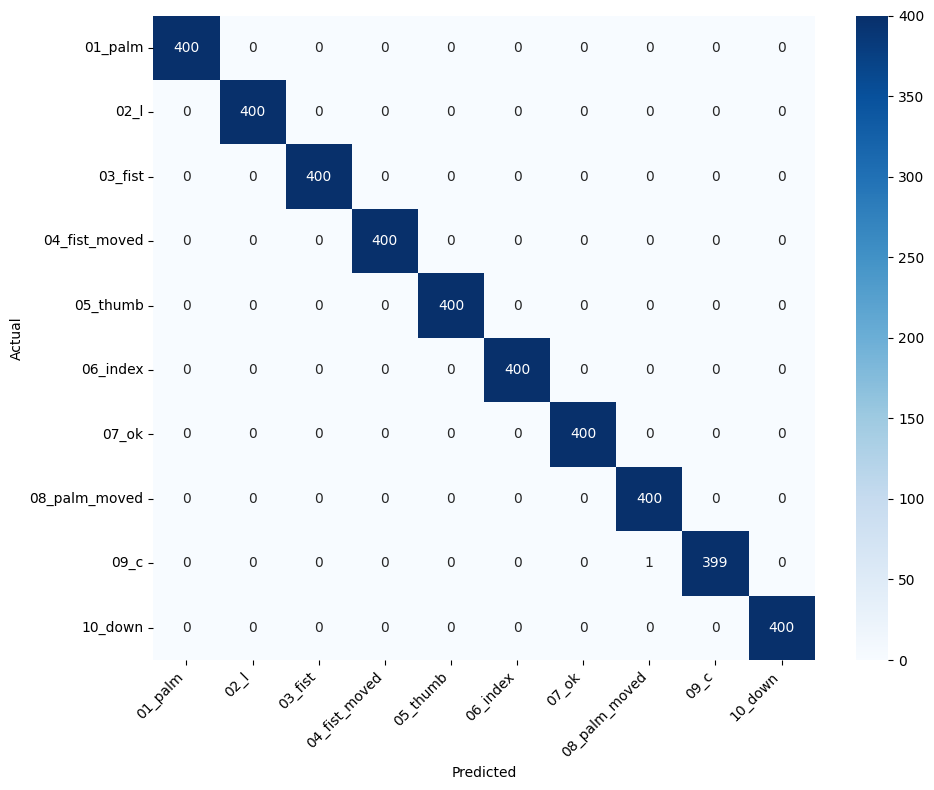

In [29]:

# CLASSIFICATION REPORT AND CONFUSION MATRIX

pred = np.argmax(model.predict(X_test), axis=1)
true = np.argmax(y_test, axis=1)

print(classification_report(true, pred, target_names=gesture_names))

cm = confusion_matrix(true, pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=gesture_names, yticklabels=gesture_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


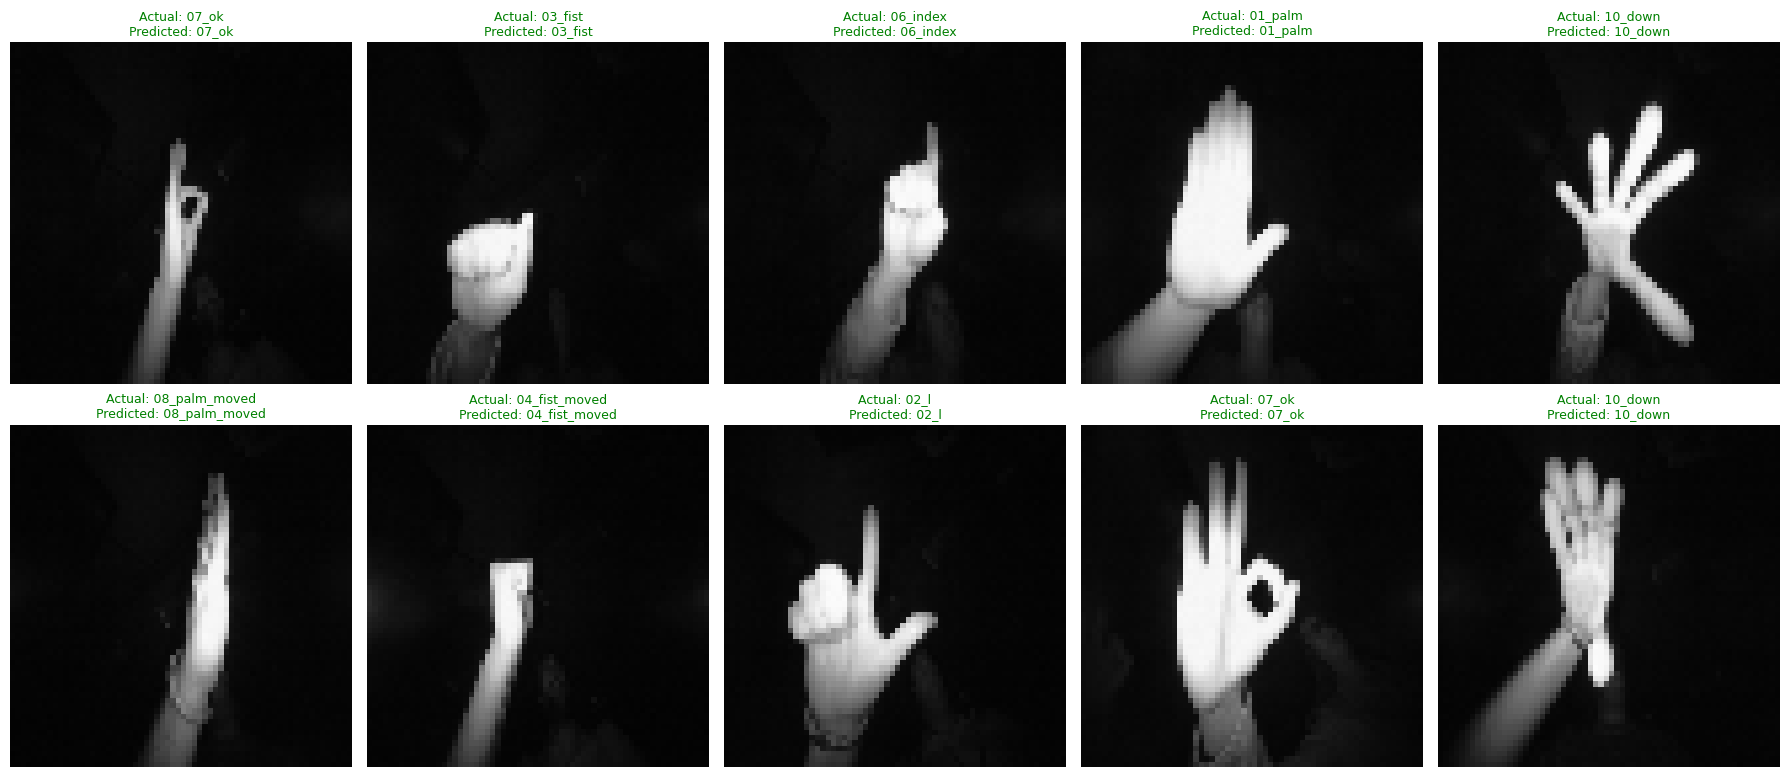

In [30]:
# VISUALIZE SOME PREDICTIONS
# FIX: original code referenced undefined y_true/y_pred - corrected to
# use the `true`/`pred` arrays actually computed in Section 12.

plt.figure(figsize=(18, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(cv2.cvtColor(X_test[i], cv2.COLOR_BGR2RGB))  # OpenCV loads as BGR

    actual = reverse_lookup[true[i]]
    predicted = reverse_lookup[pred[i]]
    color = "green" if actual == predicted else "red"

    plt.title(f"Actual: {actual}\nPredicted: {predicted}", color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [32]:
# 3-FOLD STRATIFIED CROSS-VALIDATION
# FIX: original code had this loop as empty comments ("# Build model",
# "# Train model", "# Evaluate model") with no actual model ever built -
# scores.append(acc) was just re-appending one leftover value 5 times,
# making "Mean Accuracy"/"Std Dev" meaningless. This version actually
# builds, trains, and evaluates a fresh model on each of the 5 splits.
# NOTE: this trains 5 full models - it will take a while to run.

sss = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)
scores = []

for fold, (train_idx, test_idx) in enumerate(sss.split(X, y)):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y_cat[train_idx], y_cat[test_idx]

    fold_model = build_model()
    fold_early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    fold_model.fit(
        X_tr, y_tr,
        batch_size=32,
        epochs=15,
        validation_split=0.2,
        shuffle=True,
        callbacks=[fold_early_stop],
        verbose=0
    )

    _, fold_acc = fold_model.evaluate(X_te, y_te, verbose=0)
    scores.append(fold_acc)
    print(f"Fold {fold + 1}: accuracy = {fold_acc:.4f}")

print("\nMean Accuracy:", round(np.mean(scores), 4))
print("Std Dev:", round(np.std(scores), 4))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: accuracy = 0.9995
Fold 2: accuracy = 0.9998
Fold 3: accuracy = 0.9995

Mean Accuracy: 0.9996
Std Dev: 0.0001
